⚡ Carregando Modelo Base no modo: CUDA...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

📦 Plugando o adaptador LoRA (LCM)...


No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


✅ LoRA ativado com sucesso!
🎨 Gerando imagem em 4 passos...


  0%|          | 0/4 [00:00<?, ?it/s]

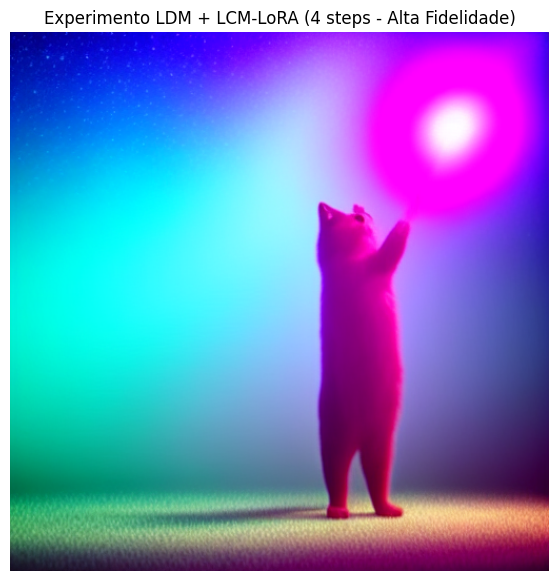

✅ Experimento concluído com sucesso!


In [4]:
# 1. Remove o torchao problemático do Colab e garante as bibliotecas certas
!pip uninstall -y torchao
!pip install -q diffusers transformers accelerate peft

import torch
from diffusers import StableDiffusionPipeline, LCMScheduler
import matplotlib.pyplot as plt

# 2. Carrega o SD 1.5 FP16 (~1.7 GB)
model_id = "runwayml/stable-diffusion-v1-5"
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"⚡ Carregando Modelo Base no modo: {device.upper()}...")
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    variant="fp16",
    use_safetensors=True
).to(device)

# 3. Configura o Scheduler do LCM
pipe.scheduler = LCMScheduler.from_config(pipe.scheduler.config)

# 4. Pluga o adaptador LCM-LoRA
print("📦 Plugando o adaptador LoRA (LCM)...")
pipe.load_lora_weights("latent-consistency/lcm-lora-sdv1-5")
print("✅ LoRA ativado com sucesso!")

# 5. Geração fotorrealista em apenas 4 passos (alta qualidade)
prompt = "A majestic wizard cat wearing a starry purple robe, holding a glowing magic staff, cinematic lighting, photorealistic, 8k"

print("🎨 Gerando imagem em 4 passos...")
image = pipe(
    prompt=prompt,
    num_inference_steps=4,  # LCM roda perfeitamente em 4 passos
    guidance_scale=1.5      # Guidance baixo essencial para o LCM
).images[0]

# 6. Exibição da imagem
plt.figure(figsize=(7, 7))
plt.imshow(image)
plt.axis('off')
plt.title("Experimento LDM + LCM-LoRA (4 steps - Alta Fidelidade)", fontsize=12)
plt.show()

print("✅ Experimento concluído com sucesso!")